In [1]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import re
import pandas as pd
import nltk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, jaccard_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer
from gensim.models import Word2Vec, FastText
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
%config InlineBackend.figure_format="retina"  # For high DPI display

# Data Processing

We have two files from which we're going to extract the data needed for our dataset.

The data is extracted from both files and cleaned, then the two resulting dataframes are merged to obtain the final dataset with titles of the movies and their corresponding genres and plots.

In [3]:
filtered_lines = []
start_reading = False

with open("genres.list", "r", encoding="ISO-8859-1") as f:
    for line in f:
        if "8: THE GENRES LIST" in line:
            start_reading = True
            continue

        if start_reading:
            filtered_lines.append(line.strip())


filtered_lines = filtered_lines[2:]
data = []
for i in filtered_lines:
    unpack = i.split("\t")
    data.append((unpack[0], unpack[-1]))

genres_df = pd.DataFrame(data, columns=["Title", "Genre"])
genres_df['Title'] = genres_df['Title'].str.replace(r'\(.*\)', '', regex=True)
genres_df['Title'] = genres_df['Title'].str.replace(r'["{}]',"",regex=True).str.strip()
genres_df.head()

,Title,Genre
0,!Next?,Documentary
1,#1 Single,Reality-TV
2,#15SecondScare,Horror
3,#15SecondScare,Short
4,#15SecondScare,Thriller


In [4]:
with open("plot.list", "r", encoding="ISO-8859-1") as file:
    lines = file.readlines()

movies = []
current_movie = None
current_plot = []

for line in lines:
    mv_match = re.match(r"MV: (.*)", line)
    pl_match = re.match(r"PL: (.*)", line)

    if mv_match:
        if current_movie and current_plot:
            movies.append({"Title": current_movie, "Plot": " ".join(current_plot)})
        current_movie = mv_match.group(1).strip()
        current_plot = []

    elif pl_match and current_movie:
        current_plot.append(pl_match.group(1).strip())

if current_movie and current_plot:
    movies.append({"Title": current_movie, "Plot": " ".join(current_plot)})

plot_df = pd.DataFrame(movies)
plot_df['Title'] = plot_df['Title'].str.replace(r'\(.*\)', '', regex=True)
plot_df['Title'] = plot_df['Title'].str.replace(r'["{}]',"",regex=True).str.strip()
plot_df.head()

,Title,Plot
0,#7DaysLater,#7dayslater is an interactive comedy series fe...
1,#BlackLove,"This week, the five women work on getting what..."
2,#BlackLove,"With just one week left in the workshops, the ..."
3,#BlackLove,All of the women are struggling with what make...
4,#BlackLove,All of the women start making strides towards ...


In [5]:
df = genres_df.merge(plot_df, on='Title', how='inner')
df.head()

,Title,Genre,Plot
0,#7DaysLater,Comedy,#7dayslater is an interactive comedy series fe...
1,#BlackLove,Reality-TV,"This week, the five women work on getting what..."
2,#BlackLove,Reality-TV,"With just one week left in the workshops, the ..."
3,#BlackLove,Reality-TV,All of the women are struggling with what make...
4,#BlackLove,Reality-TV,All of the women start making strides towards ...


Out of the genres present in the dataset, 20 are selected for the study. The movies of other genres are removed.

Some of the movies in the dataset have no titles. We choose to remove them as well.

Lastly, movies with multiple genres have repeated rows where only the genre differs. We decide to group the movies by their titles and plots to obtain a compact dataset with movies occurring only once and with their corresponding genres stores in a tuple.

In [6]:
genres = ['Comedy', 'Romance', 'Action', 'Drama', 'Horror',
       'Family', 'Sci-Fi', 'Crime', 'Mystery', 'Biography',
       'Adventure', 'History', 'War', 'Fantasy',
       'Thriller', 'Sport', 'Documentary', 'Animation',
       'Adult', 'Western']

df = df[df["Genre"].isin(genres)]
df = df[df['Title'] != ""]
df = df.groupby(['Title', 'Plot'])['Genre'].agg(tuple).reset_index()
df["Genre"] = df["Genre"].apply(lambda x: tuple(set(x)))
df = df.drop_duplicates(subset=["Title", "Genre"])
df.head()

,Title,Plot,Genre
0,#7DaysLater,#7dayslater is an interactive comedy series fe...,"(Comedy,)"
1,#Cake,#CAKE is a hour-long serial narrative comedy a...,"(Drama, Comedy)"
2,#DaddyLeaks,The life of four close friends in their late t...,"(Comedy,)"
3,#DearGeorgette,"Call me crazy, call me brave, call me neither ...","(Romance,)"
7,#Elmira,#Elmira follows the story of a bunch of strang...,"(Comedy,)"


Next, we remove the movies having a number of genres bigger than six since these are rare and they wouldn't be useful for our task.

In [7]:
df["num_cat"] = df["Genre"].apply(lambda x: len(x))
df = df[df["num_cat"] <= 6]
df = df.reset_index()
df.head()

<ipython-input-7-df5ac7c82a0a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_cat"] = df["Genre"].apply(lambda x: len(x))


,index,Title,Plot,Genre,num_cat
0,0,#7DaysLater,#7dayslater is an interactive comedy series fe...,"(Comedy,)",1
1,1,#Cake,#CAKE is a hour-long serial narrative comedy a...,"(Drama, Comedy)",2
2,2,#DaddyLeaks,The life of four close friends in their late t...,"(Comedy,)",1
3,3,#DearGeorgette,"Call me crazy, call me brave, call me neither ...","(Romance,)",1
4,7,#Elmira,#Elmira follows the story of a bunch of strang...,"(Comedy,)",1


Now, we show the number of movies per genre to have an idea about the distribution of the movies.

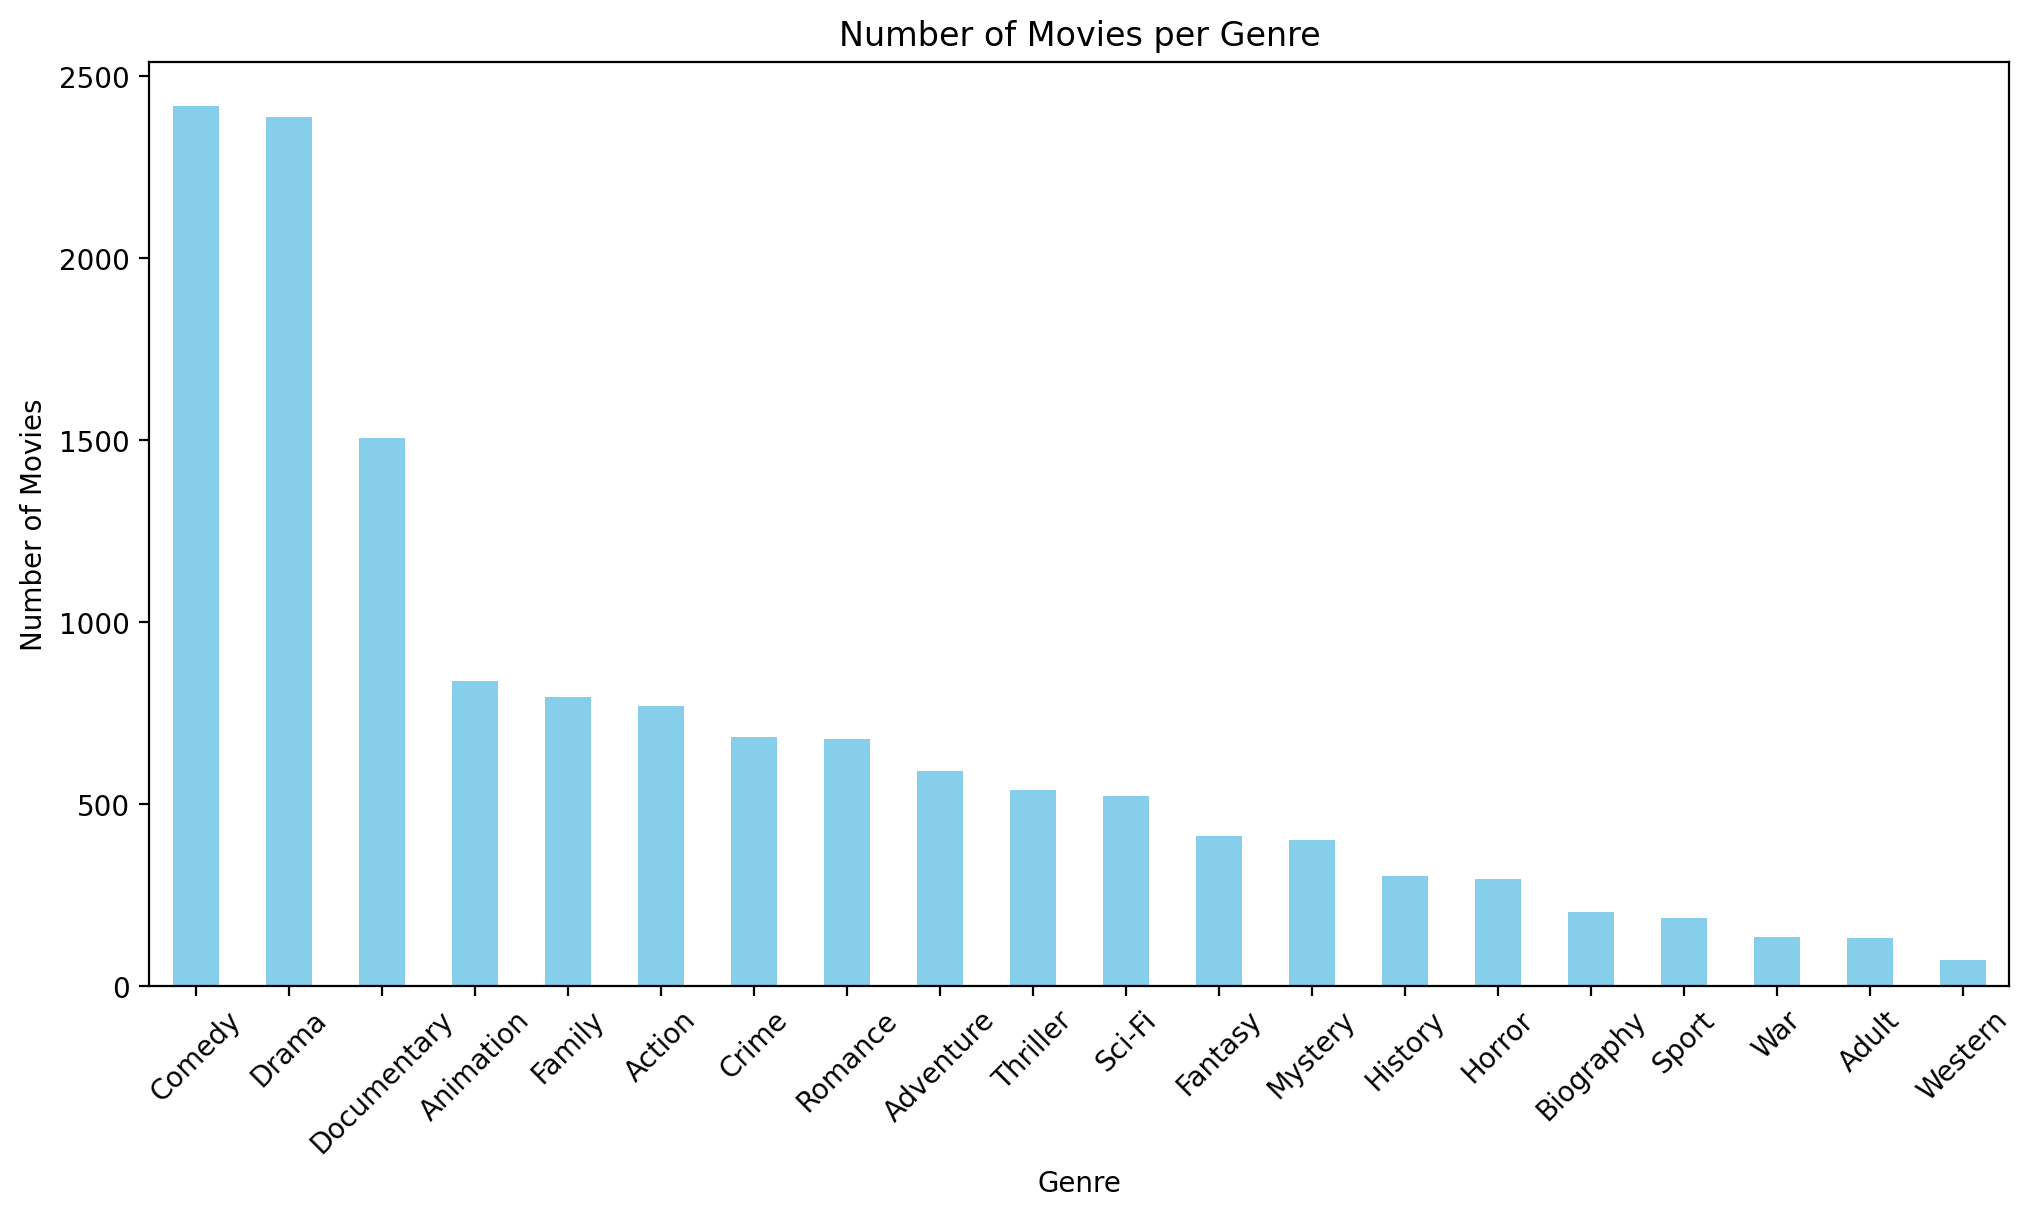

In [8]:
genre_counts = df.explode('Genre')['Genre'].value_counts()

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

Next, we check the disribution of the number of genres per movie.

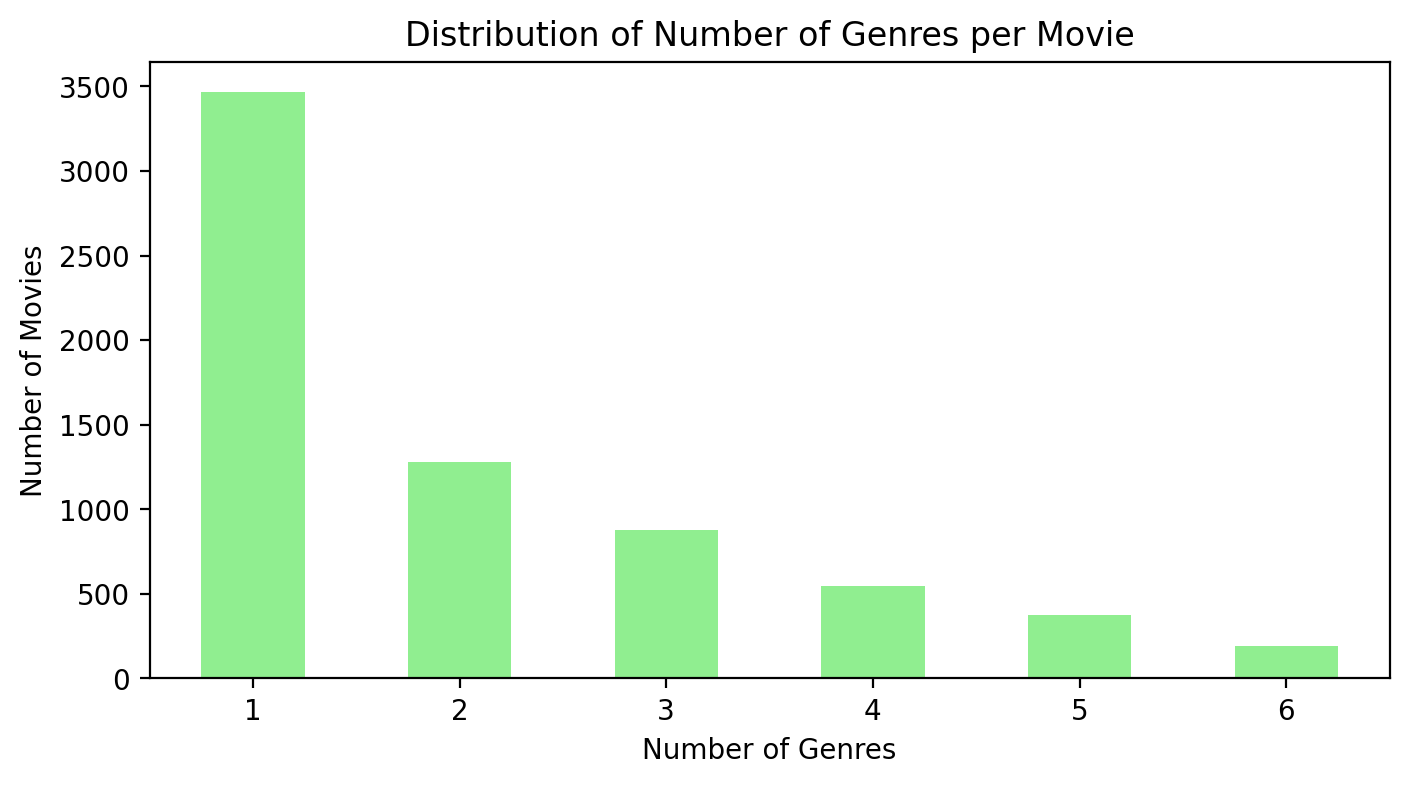

In [9]:
genre_per_movie_counts = df['Genre'].apply(len).value_counts().sort_index()

plt.figure(figsize=(8, 4))
genre_per_movie_counts.plot(kind='bar', color='lightgreen')
plt.title('Distribution of Number of Genres per Movie')
plt.xlabel('Number of Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.show()

We plot the percentage of movies by number of genres.

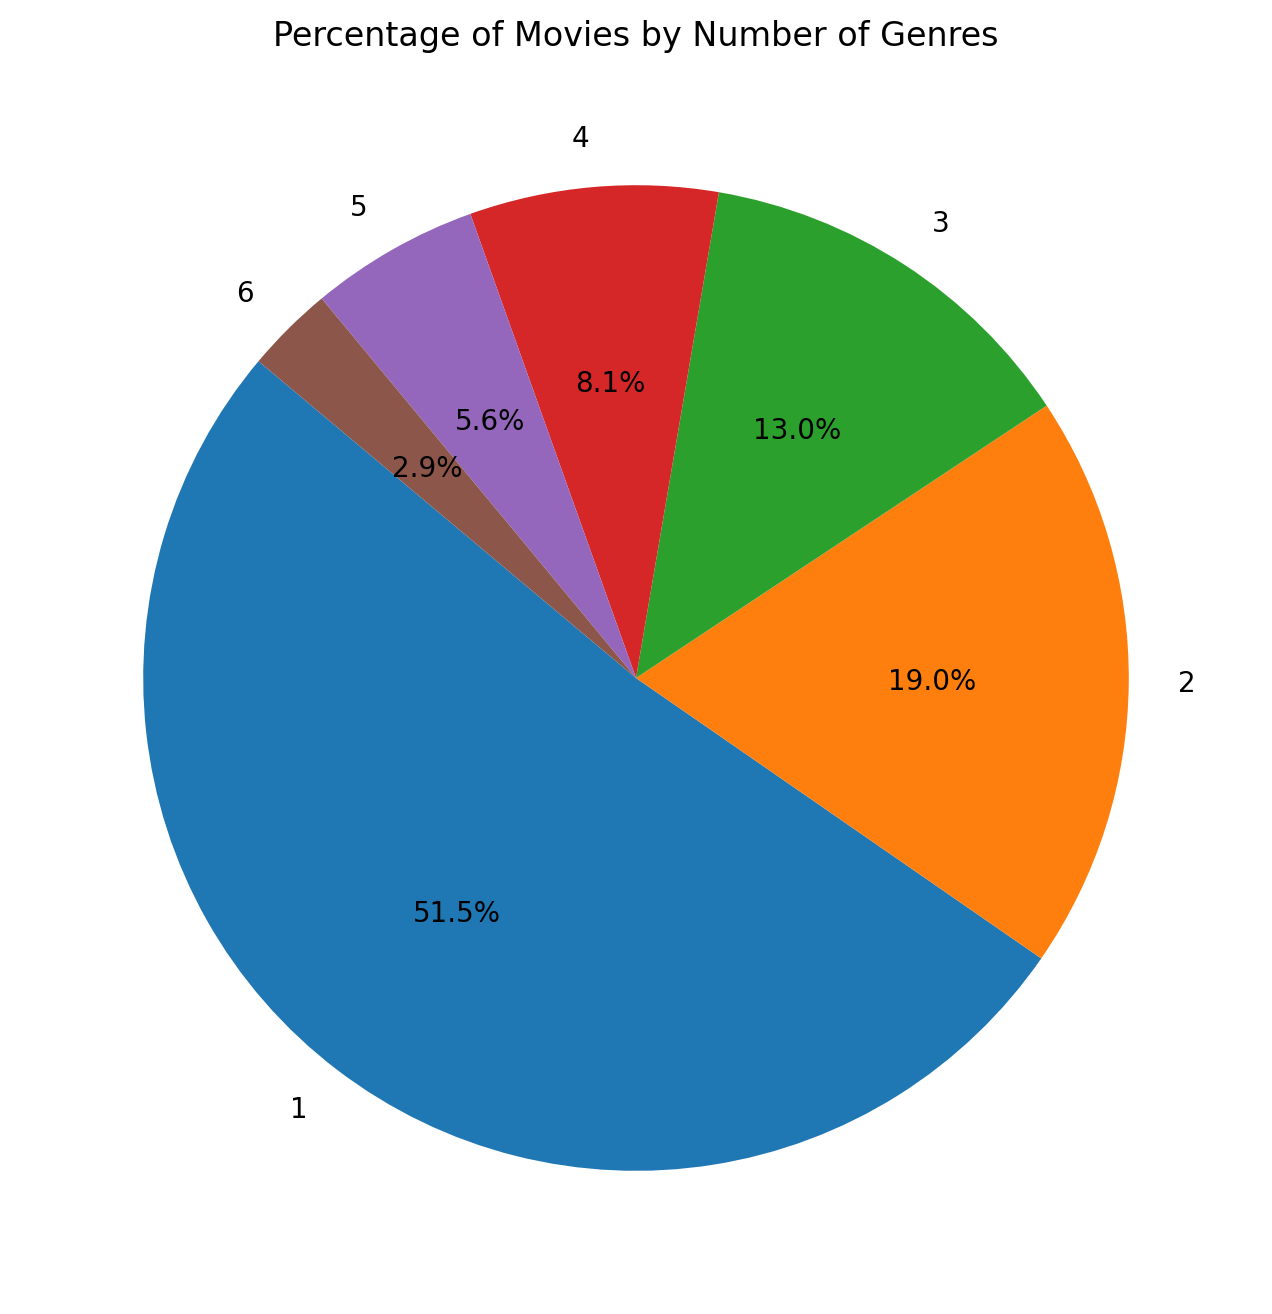

In [10]:
df_percentages = df["num_cat"].value_counts(normalize=True).reset_index()
df_percentages.columns = ["num_cat", "percentage"]
df_percentages["percentage"] = df_percentages["percentage"] * 100

plt.figure(figsize=(8, 8))
plt.pie(df_percentages['percentage'], labels=df_percentages['num_cat'], autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Movies by Number of Genres')
plt.show()

This is the final version of the dataset after data processing.

In [11]:
df = df.loc[:, ["Plot", "Genre"]]
df.head()

,Plot,Genre
0,#7dayslater is an interactive comedy series fe...,"(Comedy,)"
1,#CAKE is a hour-long serial narrative comedy a...,"(Drama, Comedy)"
2,The life of four close friends in their late t...,"(Comedy,)"
3,"Call me crazy, call me brave, call me neither ...","(Romance,)"
4,#Elmira follows the story of a bunch of strang...,"(Comedy,)"


# Tokenisation

In this section, we perform tokenization and we keep the output in our dataframe as it will be used all along our study.

We're going to keep only plots that have 200 tokens or less.

In [12]:
nltk.data.path.append('/root/nltk_data')

nltk.download("punkt_tab")
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
stop_words = set(stopwords.words('english'))

# Function to Tokenize and Remove Stopwords
def clean_plot(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return tokens if len(tokens) <= 200 else None

df["Tokenized"] = df["Plot"].apply(clean_plot)
df = df.dropna(subset=["Tokenized"])
df = df.reset_index()
df.head()

,index,Plot,Genre,Tokenized
0,0,#7dayslater is an interactive comedy series fe...,"(Comedy,)","[interactive, comedy, series, featuring, ensem..."
1,1,#CAKE is a hour-long serial narrative comedy a...,"(Drama, Comedy)","[cake, serial, narrative, comedy, manhunt, hig..."
2,2,The life of four close friends in their late t...,"(Comedy,)","[life, four, close, friends, late, thirties, c..."
3,3,"Call me crazy, call me brave, call me neither ...","(Romance,)","[call, crazy, call, brave, call, neither, coup..."
4,4,#Elmira follows the story of a bunch of strang...,"(Comedy,)","[elmira, follows, story, bunch, strangers, res..."


Since our dataset contains multiple classes, the target variable is stored as a tuple with categorical values. We construct a matrix y, where each row represents a movie and each column corresponds to a specific genre. If a movie belongs to a particular genre, the respective column is assigned a value of 1; otherwise, it is assigned 0.

In [14]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Genre"])
genre_names = mlb.classes_

------------

# TF-IDF

In this section, we use TF-IDF to classify movies given their plots.

The following models are used to perform the classification task:
- Logistic Regression (One Vs Rest)
- SVC
- XGBoost

In [15]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['Plot'])

In [16]:
X.shape

(6680, 5000)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 5678
Testing samples: 1002


Before making our models, we visualise the PCA projection of the movies in order to get an idea about the variety of the textual features of the movies from the different genres.

In order to simplify the task, only movies having one genre were considered, which amounts to 50% of the total data. (It's more complicated to visualise also the movies having multiple genres)

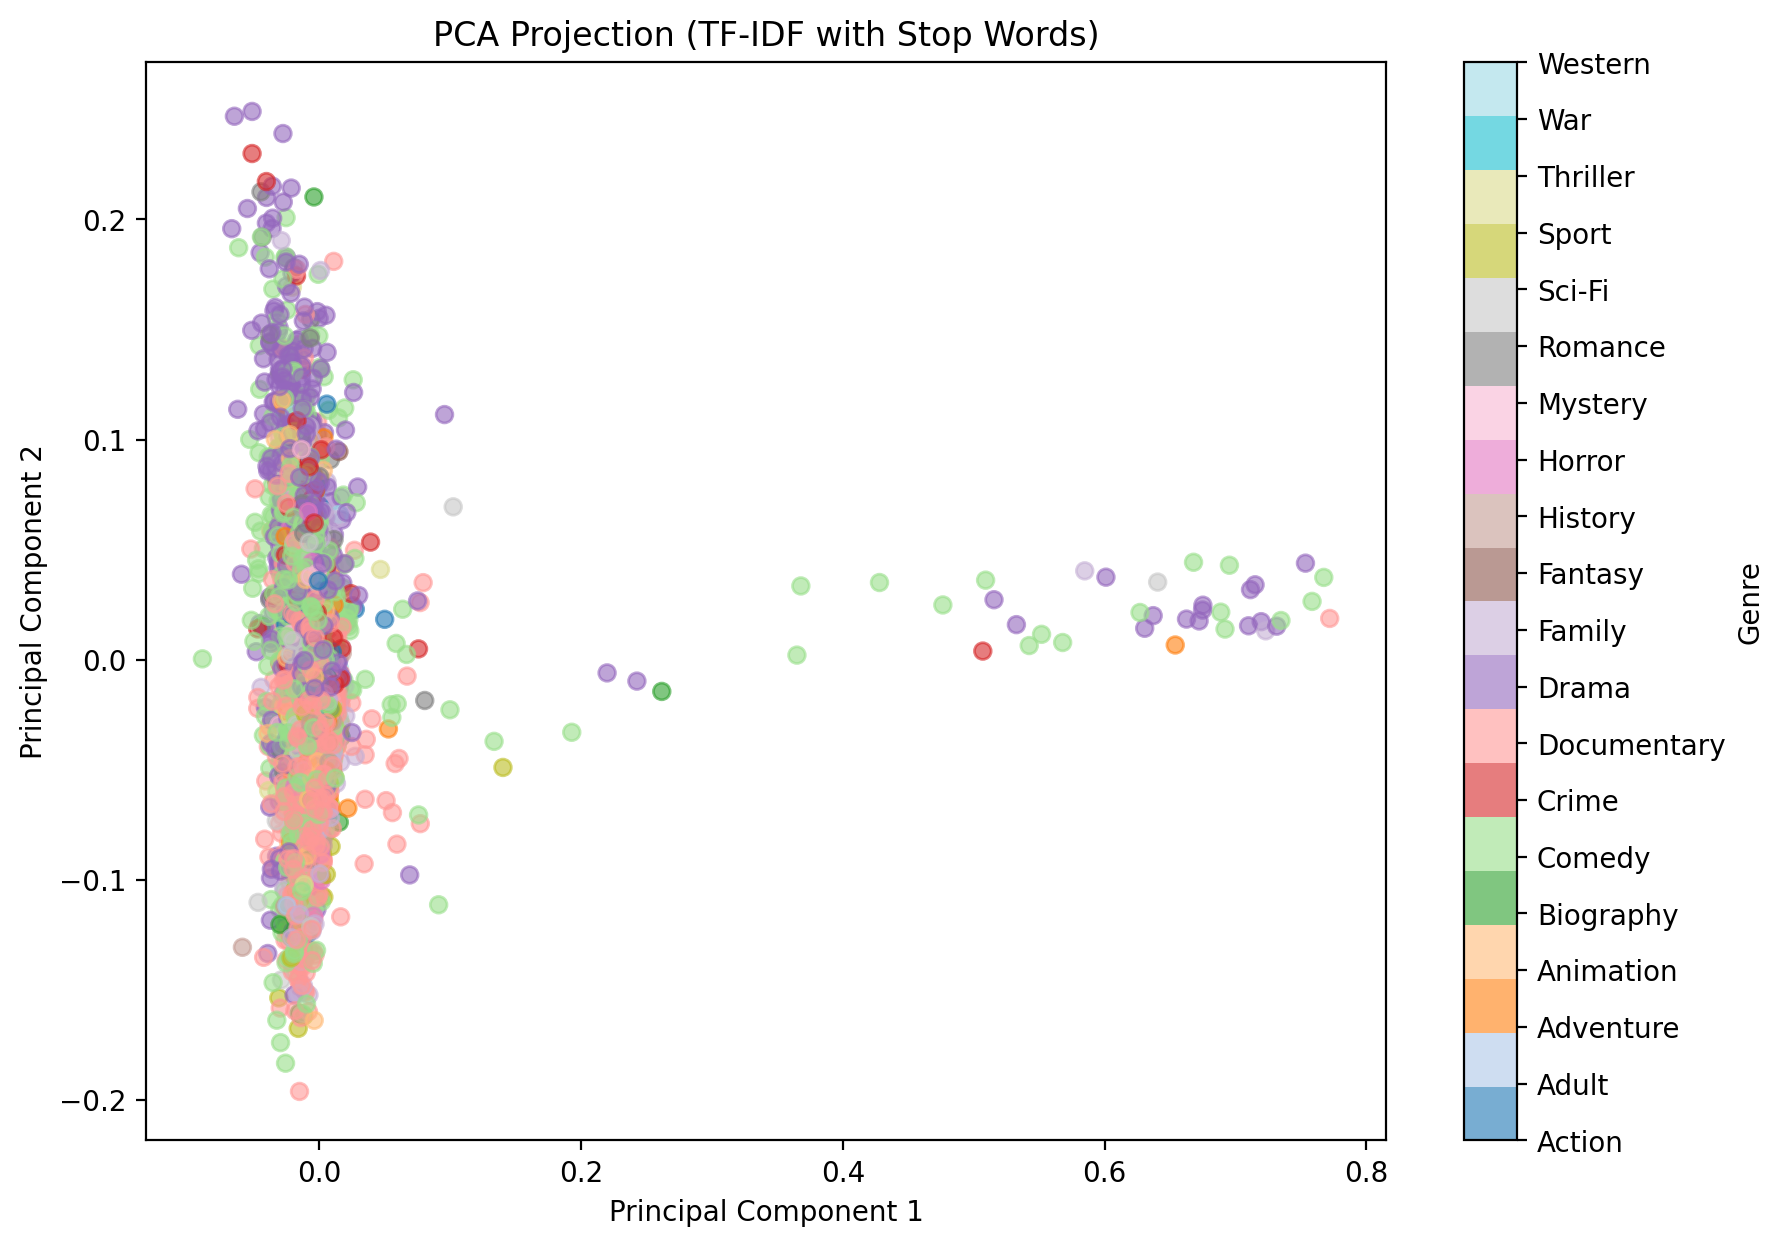

In [18]:
# Filter data with only single-genre movies
single_genre_mask = df['Genre'].apply(lambda x: len(x) == 1)

# Extract the plots and their single genre labels
single_genre_plots = df.loc[single_genre_mask, 'Plot']
single_genre_labels = df.loc[single_genre_mask, 'Genre'].apply(lambda x: x[0])

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_single_genre = vectorizer.fit_transform(single_genre_plots)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_single_genre.toarray())

def plot_pca_projection(pca_data, labels, title):
    unique_labels = np.unique(labels)
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    color_labels = [label_to_int[label] for label in labels]

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=color_labels, cmap="tab20", alpha=0.6)
    cbar = plt.colorbar(scatter, ticks=range(len(unique_labels)))
    cbar.set_ticklabels(unique_labels)
    cbar.set_label('Genre')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.show()

plot_pca_projection(X_pca, single_genre_labels, "PCA Projection (TF-IDF with Stop Words)")

The PCA projection of TF-IDF vectors for movie plots shows significant overlap among genres, indicating that many movies share common textual features, which complicates genre prediction based solely on plot descriptions. Visible clusters are sparse, suggesting that distinguishing genres using TF-IDF alone may be challenging. One thing to keep in mind is the loss of information inherent in dimensionality reduction. Therefore we will check next if the observation is correct and if this overlap underscores the necessity for more sophisticated modeling approaches.

Next, we define a function returning some metrics that will be useful for our analysis:

In [19]:
def metrics(y_test, y_pred, genre_names):
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    f1 = f1_score(y_test, y_pred, average='micro')
    print(f"F1 Score: {f1:.4f}")

    jaccard_weighted = jaccard_score(y_test, y_pred, average='samples')
    print(f"Jaccard Index (Samples): {jaccard_weighted:.4f}")

    hit_rate = np.mean(np.sum(y_test * y_pred, axis=1) > 0)
    print(f"Hit Rate: {hit_rate:.4f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=genre_names))

### Logistic Regression

In [20]:
model = Pipeline([
    ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear')))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.1627
F1 Score: 0.2922
Jaccard Index (Samples): 0.2347
Hit Rate: 0.3483

Classification Report:
               precision    recall  f1-score   support

      Action       1.00      0.01      0.02       113
       Adult       0.00      0.00      0.00        17
   Adventure       0.00      0.00      0.00        81
   Animation       0.67      0.04      0.07       113
   Biography       0.00      0.00      0.00        25
      Comedy       0.73      0.42      0.53       355
       Crime       0.85      0.10      0.17       113
 Documentary       0.82      0.32      0.46       224
       Drama       0.69      0.36      0.48       347
      Family       0.00      0.00      0.00        99
     Fantasy       0.00      0.00      0.00        49
     History       0.00      0.00      0.00        48
      Horror       0.00      0.00      0.00        54
     Mystery       0.00      0.00      0.00        69
     Romance       0.00      0.00      0.00        85
      Sci-Fi       1.00    

### SVC

In [21]:
model = Pipeline([
    ('clf', OneVsRestClassifier(LinearSVC()))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.1876
F1 Score: 0.4057
Jaccard Index (Samples): 0.3300
Hit Rate: 0.5529

Classification Report:
               precision    recall  f1-score   support

      Action       0.59      0.12      0.19       113
       Adult       0.00      0.00      0.00        17
   Adventure       0.30      0.07      0.12        81
   Animation       0.63      0.34      0.44       113
   Biography       0.00      0.00      0.00        25
      Comedy       0.63      0.56      0.59       355
       Crime       0.62      0.23      0.34       113
 Documentary       0.67      0.50      0.57       224
       Drama       0.55      0.48      0.51       347
      Family       0.35      0.18      0.24        99
     Fantasy       0.44      0.08      0.14        49
     History       0.75      0.12      0.21        48
      Horror       0.50      0.04      0.07        54
     Mystery       0.11      0.01      0.03        69
     Romance       0.36      0.09      0.15        85
      Sci-Fi       0.56    

### XGBoost

In [22]:
model = XGBClassifier(eval_metric='logloss', objective='binary:logistic')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics(y_test, y_pred, genre_names)

Accuracy: 0.1587
F1 Score: 0.3319
Jaccard Index (Samples): 0.2562
Hit Rate: 0.4192

Classification Report:
               precision    recall  f1-score   support

      Action       0.57      0.07      0.13       113
       Adult       0.00      0.00      0.00        17
   Adventure       0.27      0.05      0.08        81
   Animation       0.50      0.16      0.24       113
   Biography       0.00      0.00      0.00        25
      Comedy       0.66      0.41      0.50       355
       Crime       0.62      0.27      0.37       113
 Documentary       0.72      0.35      0.47       224
       Drama       0.58      0.38      0.46       347
      Family       0.29      0.06      0.10        99
     Fantasy       0.38      0.06      0.11        49
     History       0.67      0.12      0.21        48
      Horror       0.50      0.02      0.04        54
     Mystery       0.29      0.03      0.05        69
     Romance       0.25      0.09      0.14        85
      Sci-Fi       0.64    

------------

# Word2vec

In this section, we use Word2Vec embedding trained from scratch.

The models used for the classification task are:
- XGBoost
- GRU
- CNN

In [23]:
word2vec_model = Word2Vec(sentences=df["Tokenized"], vector_size=100, window=5, min_count=1, workers=4)

In [24]:
def get_sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

df["W2V Embedding"] = df["Tokenized"].apply(lambda x: get_sentence_embedding(x, word2vec_model))
X = np.vstack(df["W2V Embedding"].values)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### XGBoost

In [ ]:
pipeline_xgb = Pipeline([
    ('pca', PCA()),
    ('xgb', XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss"))
])

param_dist_xgb = {
    'pca__n_components': randint(10, 80),
    'xgb__n_estimators': randint(50, 300),
    'xgb__max_depth': randint(2, 10),
    'xgb__learning_rate': uniform(0.01, 0.2),
}

random_search_xgb = RandomizedSearchCV(pipeline_xgb, param_distributions=param_dist_xgb, n_iter=5,
                                       cv=3, scoring='accuracy', verbose=0, n_jobs=-1, random_state=42)

random_search_xgb.fit(X_train, y_train)
print("Best XGBoost Parameters:", random_search_xgb.best_params_)

xgb_best = random_search_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

In [ ]:
metrics(y_test, y_pred_xgb, genre_names)

### GRU

In [ ]:
X_train_gru = np.expand_dims(X_train_pca, axis=1)
X_test_gru = np.expand_dims(X_test_pca, axis=1)

gru_model = Sequential([
    GRU(100, input_shape=(1, 100), return_sequences=False),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='sigmoid')
])


gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train, epochs=10, batch_size=32, validation_data=(X_test_gru, y_test))
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)

In [ ]:
metrics(y_test, y_pred_gru, genre_names)

### CNN

In [ ]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='sigmoid')  # Multi-label classification
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Input shape
input_shape = (X_train.shape[1], 1)
num_classes = y_train.shape[1]

# Reshape input for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.summary()
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))

y_pred = cnn_model.predict(X_test_cnn)
y_pred = (y_pred > 0.5).astype(int)

In [ ]:
metrics(y_test, y_pred, genre_names)

------------

## FastText

In this section, we use FastText embedding.

The models used for the classification task are:
- XGBoost
- GRU

In [ ]:
fasttext_model = FastText(
    sentences=df["Tokenized"],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

def get_sentence_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)


df["FT Embedding"] = df["Tokenized"].apply(lambda x: get_sentence_embedding(x, fasttext_model))
X = np.vstack(df["FT Embedding"].values)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### XGBoost

In [ ]:
xgb_model = XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
metrics(y_test, y_pred_xgb)

### GRU

In [ ]:
X_train_gru = np.expand_dims(X_train, axis=1)
X_test_gru = np.expand_dims(X_test, axis=1)

gru_model = Sequential([
    GRU(128, input_shape=(1, 100), return_sequences=False),
    Dropout(0.3),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='sigmoid')
])

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.fit(X_train_gru, y_train, epochs=10, batch_size=32, validation_data=(X_test_gru, y_test))
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)
print("GRU Classification Report:\n", classification_report(y_test, y_pred_gru, target_names=genre_names))

In [ ]:
metrics(y_test, y_pred_gru, genre_names)

-------------------

## Doc2vec

In this section, we use Doc2Vec embedding.

The models used for the classification task are:
- Naïve Bayes
- XGBoost
- CNN


In [ ]:
tagged_data = [TaggedDocument(words=row, tags=[str(i)]) for i, row in enumerate(df["Tokenized"])]

# Train Doc2Vec model
doc2vec_model = Doc2Vec(vector_size=100, window=5, min_count=1, workers=4, epochs=20)
doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(tagged_data, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

# Convert Tokenized text into vectors
def get_doc_embedding(words, model):
    return model.infer_vector(words)

df["Doc2Vec Embedding"] = df["Tokenized"].apply(lambda x: get_doc_embedding(x, doc2vec_model))
X = np.vstack(df["Doc2Vec Embedding"].values)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

### Naïve Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [ ]:
metrics(y_test, y_pred, genre_names)

### XGBoost

In [ ]:
xgb_model = XGBClassifier(objective="binary:logistic", use_label_encoder=False, eval_metric="logloss", n_estimators=100)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
metrics(y_test, y_pred_xgb, genre_names)

### CNN

In [ ]:
# Reshape input for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [ ]:
# Define CNN model
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='sigmoid')  # Multi-label classification
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Input shape
input_shape = (X_train.shape[1], 1)
num_classes = y_train.shape[1]

cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.summary()
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_data=(X_test_cnn, y_test))

y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int)

In [ ]:
metrics(y_test, y_pred_cnn, genre_names)